In [1]:
import matplotlib.pyplot as plt
import datetime

time = datetime.datetime.now().isoformat()
print("Time: ", time)

import PIL.Image as Image
import numpy as np
from decluttering.data.utils.detic_dataloader import DeticDataloader
import matplotlib.pyplot as plt

detic = DeticDataloader()
detic.create()
detic.default_vocab()

Time:  2024-06-27T14:28:51.934724


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


Inference time:  1.2728126049041748


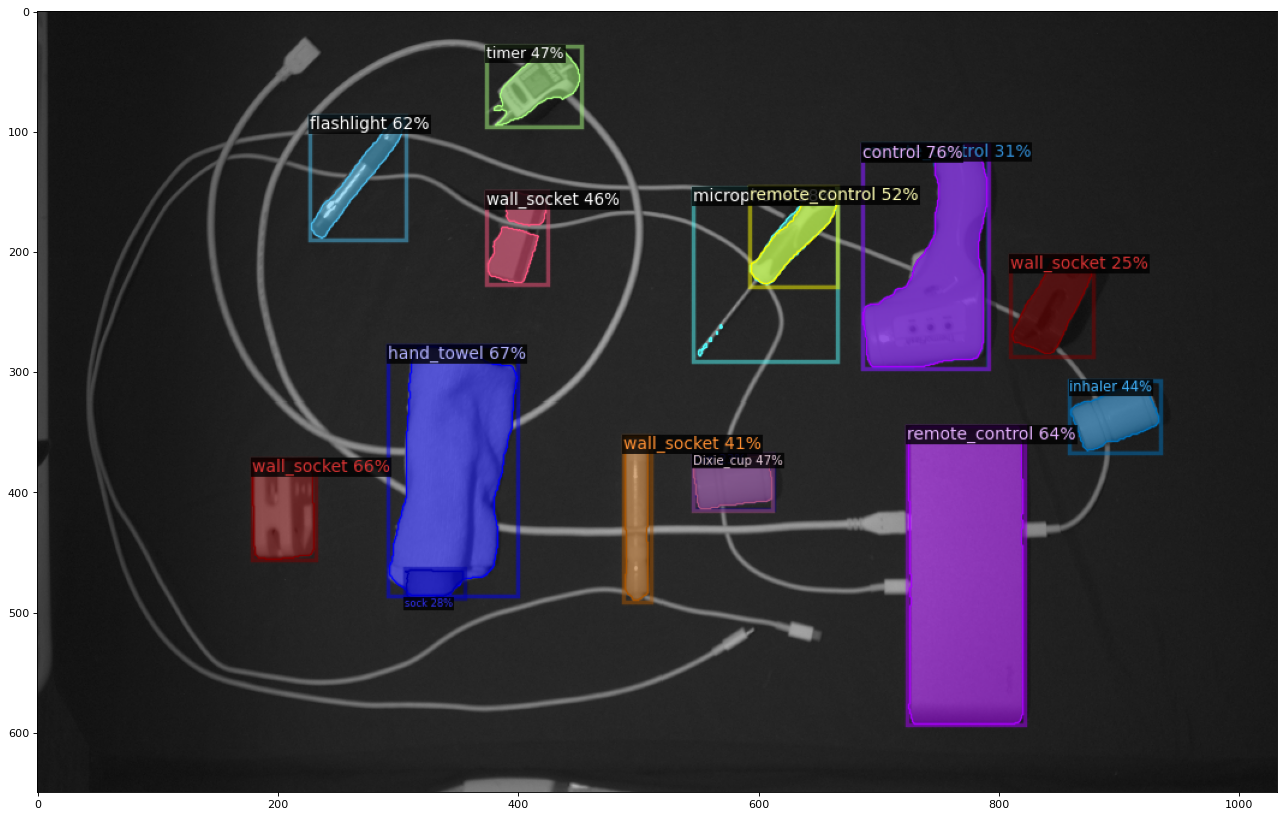

In [2]:

im_frame1 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/intensity_image2024-06-27T14:27:27.920319.png')
# im_frame1 = im_frame1.resize((640, 480))
# im_frame1 = frame.color.data
np_frame1 = np.array(im_frame1)

# remove alpha channel
np_frame1 = np_frame1[0:650, :, :3]

out = detic.predict(np_frame1)
output_im = out['vis'].get_image()
# print(output_im.shape)
plt.figure(figsize=(20, 18), dpi=80)
plt.imshow(output_im)


Number of masks before filtering torch.Size([16, 1, 650, 1032])
Area of masks before filtering tensor([11232, 16325,  4138, 23482,  1800,  2303,  2520,  2402,  2197,  2640,
         2633, 11270,   981,  2447,  3023,  2407], device='cuda:0')
torch.Size([15, 1, 650, 1032])


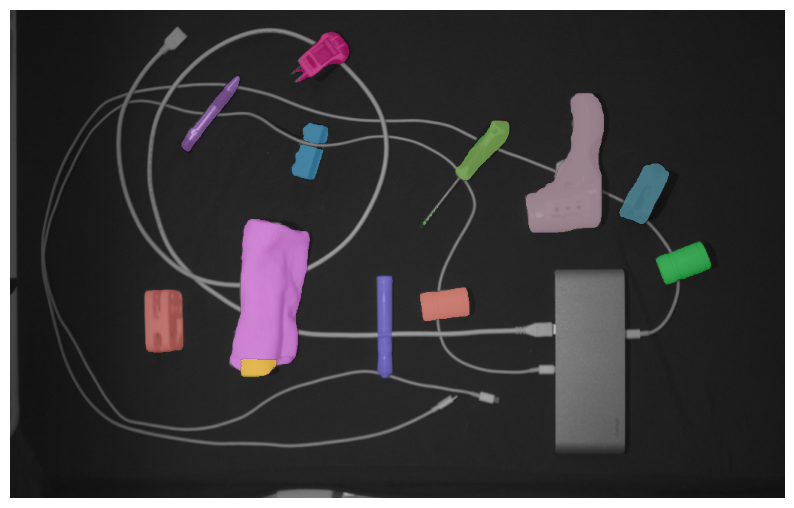

In [4]:

import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 17000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

def get_largest_mask(masks):
    sorted, indices = torch.sort(torch.sum(masks, dim = (1,2,3)), descending=True)
    return masks[indices[0]]

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]

detic.visualize_output(np_frame1, filtered_areas, image_save_path=f"detic_masks/filtered_masks{time}.png")